# A regular tetrahedron: residence is different from transit

This is the first **DFND laboratory** case: a small, independently checkable
experiment that will seed a public collection of molecular-topography benchmarks.
It studies what DFND reports before asking how it compares with a pocket detector.
Four fictitious atoms are a geometric control, not a protein or a binding-site benchmark.

We freeze the input and acceptance tolerances before evaluating the implementation.
The native engine is used unchanged. Third-party execution is optional; a missing
program or a failed run remains visible and never becomes an empty pocket result.

Downloads: {download}`quantity-aware input <artifacts/regular_tetrahedron_v1/input.json>`,
{download}`provider PDB <artifacts/regular_tetrahedron_v1/input.pdb>`, and
{download}`recorded observations <artifacts/regular_tetrahedron_v1/report.json>`.
Use the development environment described in the [laboratory index](index.md).
Run all cells from this notebook's directory. No molecular files are downloaded.

In [1]:
import hashlib
import html
import json
import re
import shutil
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from pyunitwizard import QuantityRecord

import topomt as tmt
from topomt import pyunitwizard as puw
from topomt.dfnd import DelaunayFlowNetwork

ARTIFACT_DIR = Path('artifacts/regular_tetrahedron_v1')
RUN_FPOCKET = True  # Optional original-engine comparison; set False to skip it.
fixture_bytes = (ARTIFACT_DIR / 'input.json').read_bytes()
fixture = json.loads(fixture_bytes)


def quantity(field):
    return QuantityRecord.from_dict(fixture[field]).to_quantity(
        field=field, unit='angstroms'
    )


def values(field):
    return np.asarray(puw.get_value(quantity(field), to_unit='angstroms'))


def qrecord(value, unit, field):
    return QuantityRecord.from_quantity(
        puw.quantity(value, unit), field=field
    ).to_dict()


coords = values('coordinates')
radii = values('atom_radii')
edge = float(values('edge'))
probe_values = values('probe_sweep')
reference_atol = fixture['reference']['clearance_atol_angstroms']
pdb_file = ARTIFACT_DIR / fixture['provider_input']['file']
assert hashlib.sha256(pdb_file.read_bytes()).hexdigest() == fixture['provider_input']['sha256']
assert coords.shape == (4, 3) and radii.shape == (4,)
assert np.all(radii == radii[0])
pair_distances = [np.linalg.norm(coords[i] - coords[j]) for i in range(4) for j in range(i)]
np.testing.assert_allclose(pair_distances, edge, rtol=0, atol=reference_atol)

## Independent expectations

The edge length is $a=5.3$ Å and each atomic ball has radius $r_a=1.7$ Å.
The circumradius of a regular tetrahedron is $a\sqrt{6}/4$; that of each
equilateral face is $a/\sqrt{3}$. Subtracting the common atomic radius gives:

$$R_{\mathrm{residence}}=\frac{a\sqrt{6}}{4}-r_a,\qquad
R_{\mathrm{gate}}=\frac{a}{\sqrt{3}}-r_a.$$

The finite tetrahedron's hull volume is $a^3/(6\sqrt{2})$. This includes parts of
the atomic balls and is **not** a solvent or probe-accessible volume.
These formulas come from the input geometry, independently of DFND's solver.

We test three probes away from equality thresholds. Below the face clearance,
the resident cell connects to the exterior; between the face and residence
clearances, it remains resident but becomes sealed; above the residence
clearance, it has no resident node. Increasing the probe seals these gates.
The atom coordinates and radii remain fixed throughout.

In [2]:
expected_residence = edge * np.sqrt(6) / 4 - radii[0]
expected_gate = edge / np.sqrt(3) - radii[0]
expected_cell_volume = edge**3 / (6 * np.sqrt(2))
display(Markdown(
    '| Independent quantity | Value |\n|---|---:|\n'
    f'| Residence clearance | {expected_residence:.9f} Å |\n'
    f'| Face clearance | {expected_gate:.9f} Å |\n'
    f'| Finite cell hull volume | {expected_cell_volume:.9f} Å³ |'
))

| Independent quantity | Value |
|---|---:|
| Residence clearance | 1.545573909 Å |
| Face clearance | 1.359956427 Å |
| Finite cell hull volume | 17.545322710 Å³ |

## Inspect the geometric input

The grey surfaces are the four atomic balls. The central blue marker is the
residence center; orange markers are the four face centers. Dashed lines mark
the edges of the finite Delaunay cell. These centers describe clearance
primitives; they do not certify a collision-free continuous probe path.

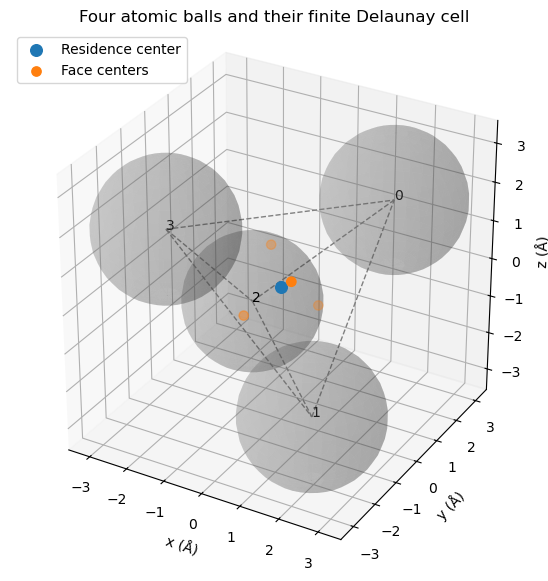

In [3]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection='3d')
azimuth = np.linspace(0, 2 * np.pi, 35)
polar = np.linspace(0, np.pi, 20)
unit_sphere = np.array([
    np.outer(np.cos(azimuth), np.sin(polar)),
    np.outer(np.sin(azimuth), np.sin(polar)),
    np.outer(np.ones_like(azimuth), np.cos(polar)),
])
for i, point in enumerate(coords):
    surface = point[:, None, None] + radii[i] * unit_sphere
    ax.plot_surface(*surface, color='grey', alpha=0.22, linewidth=0)
    ax.text(*point, str(i))
    for other in coords[:i]:
        ax.plot(*np.stack([point, other]).T, '--', color='grey', linewidth=1)
face_centers = np.array([np.delete(coords, i, axis=0).mean(axis=0) for i in range(4)])
ax.scatter(*coords.mean(axis=0), color='tab:blue', s=70, label='Residence center')
ax.scatter(*face_centers.T, color='tab:orange', s=45, label='Face centers')
limit = float(np.max(np.abs(coords)) + radii.max())
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit),
       xlabel='x (Å)', ylabel='y (Å)', zlabel='z (Å)')
ax.set_box_aspect((1, 1, 1))
ax.legend(loc='upper left')
ax.set_title('Four atomic balls and their finite Delaunay cell')
fig.subplots_adjust(left=0.02, right=0.88, bottom=0.02, top=0.9)
plt.show()

## Build once and query several probes

DFND receives explicit coordinate and radius quantities. Native raw arrays use
nanometers; we convert reported lengths and volumes to Å and Å³ for this study.
`min_size=0` retains the one-cell control, which a larger reporting filter could
otherwise hide. Counts below describe raw topology, rather than a list of
biological pockets.

In [4]:
network = DelaunayFlowNetwork.from_coordinates_and_radii(
    quantity('coordinates'), quantity('atom_radii'), epsilon=quantity('epsilon')
)
observed_residence = network.tetra_residence * 10
observed_gates = network.face_r_gates_per_tet_face * 10
np.testing.assert_allclose(observed_residence, expected_residence,
                           rtol=0, atol=reference_atol)
np.testing.assert_allclose(observed_gates, expected_gate,
                           rtol=0, atol=reference_atol)


def observe(probe):
    result = network.get_topography(
        probe_radius=puw.quantity(float(probe), 'angstroms'),
        **fixture['query'],
    )
    cell = result['raw']['tetrahedra'][0]
    components = result['raw']['wet_components']
    return {
        'probe_angstroms': float(probe),
        'residence_state': cell['residence_state'],
        'transit_role': cell['transit_role'],
        'local_class': cell['local_class'],
        'permeable_contacts': int(cell['n_permeable_contacts']),
        'wet_component_count': len(components),
        'regime': components[0]['family'] if components else 'non_resident',
        'external_links': sum(int(item['n_external_links']) for item in components),
        'cell_hull_volume_angstroms3': float(cell['volume_topological'] * 1000),
        'solvent_volume_estimate_angstroms3': float(cell['volume_solvent_estimate'] * 1000),
    }


anchors = [observe(probe) for probe in values('anchor_probes')]
assert [item['regime'] for item in anchors] == fixture['reference']['expected_anchor_regimes']
assert [item['permeable_contacts'] for item in anchors] == fixture['reference']['expected_permeable_contacts']
assert [item['external_links'] for item in anchors] == fixture['reference']['expected_external_links']
np.testing.assert_allclose([item['cell_hull_volume_angstroms3'] for item in anchors],
                           expected_cell_volume, rtol=fixture['reference']['cell_volume_rtol'])
table = '| Probe (Å) | Resident | Permeable faces | Wet family | Exterior links |\n|---:|---|---:|---|---:|\n'
table += '\n'.join(
    f"| {item['probe_angstroms']:.1f} | {item['residence_state']} | "
    f"{item['permeable_contacts']} | {item['regime']} | {item['external_links']} |"
    for item in anchors
)
display(Markdown(table))

| Probe (Å) | Resident | Permeable faces | Wet family | Exterior links |
|---:|---|---:|---|---:|
| 1.2 | resident | 4 | percolating | 1 |
| 1.4 | resident | 0 | void | 0 |
| 1.7 | non_resident | 0 | non_resident | 0 |

Four permeable exterior faces are grouped into **one external link** here;
they are not four independently detected mouths. At 1.7 Å, no resident node
does not imply that the geometric empty space vanished. This distinction is
part of DFND's richer description of residence and transit.

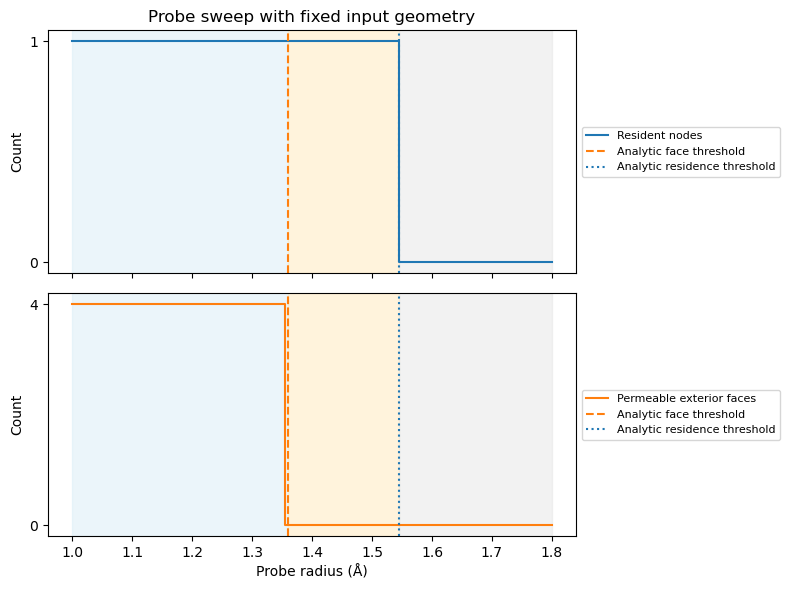

In [5]:
sweep = [observe(probe) for probe in probe_values]
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
axes[0].step(probe_values, [item['residence_state'] == 'resident' for item in sweep],
             where='mid', label='Resident nodes', color='tab:blue')
axes[1].step(probe_values, [item['permeable_contacts'] for item in sweep],
             where='mid', label='Permeable exterior faces', color='tab:orange')
colors = ['#d8edf7', '#ffe9ba', '#e6e6e6']
bounds = [probe_values.min(), expected_gate, expected_residence, probe_values.max()]
for ax in axes:
    for left, right, color in zip(bounds[:-1], bounds[1:], colors):
        ax.axvspan(left, right, color=color, alpha=0.5)
    ax.axvline(expected_gate, color='tab:orange', linestyle='--', label='Analytic face threshold')
    ax.axvline(expected_residence, color='tab:blue', linestyle=':', label='Analytic residence threshold')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
    ax.set_ylabel('Count')
axes[0].set(yticks=[0, 1], title='Probe sweep with fixed input geometry')
axes[1].set(xlabel='Probe radius (Å)', yticks=[0, 4])
fig.tight_layout()
plt.show()

## What this case does and does not validate

The independent assertions validate the two symmetric clearance primitives,
finite hull volume and three graph regimes away from numerical thresholds.
Exact equality and epsilon policy need separate marginal cases. Regression
tests also check rigid rotation and translation.

The current solvent-volume value is an **estimate**. This notebook does not
certify its error, label it an exact physical volume, or infer probe-accessible
volume from it. Precision work remains open in TopoMT issue #75. The local
clearance graph also does not by itself validate continuous probe navigation.
Analytic expectations for a regular four-atom input cannot be transferred to a
sampled spherical shell merely because its generator calls it a sphere.

## Optional comparison with original fpocket

We submit the downloadable PDB through `get_provider_output`, using the
original CLI and default detection settings. PDB rounds coordinates to 0.001 Å
and does not encode our supplied atomic radii. We report that input change and
compute DFND clearances on the rounded coordinates with the same explicit radii.
fpocket's atom interpretation, alpha-sphere filtering and pocket definitions
remain its own; no numerical or pocket-count agreement is required.

This tiny dummy-atom input can be outside a provider's supported input domain.
`execution_failed`, `unavailable`, `not_requested` and a completed zero-pocket
run are distinct outcomes. We do not change the geometry, imitate protein
residues or lower detection thresholds to manufacture a match.

In [6]:
pdb_coords = np.array([
    [float(line[30:38]), float(line[38:46]), float(line[46:54])]
    for line in pdb_file.read_text().splitlines()
    if line.startswith(('ATOM  ', 'HETATM'))
])
rounded_network = DelaunayFlowNetwork.from_coordinates_and_radii(
    puw.quantity(pdb_coords, 'angstroms'), quantity('atom_radii'),
    epsilon=quantity('epsilon'),
)
rounding_delta = float(np.max(np.abs(pdb_coords - coords)))
provider = {'name': 'fpocket', 'backend': 'cli', 'extra_args': [],
            'status': 'not_requested', 'pocket_count': None,
            'input_sha256': fixture['provider_input']['sha256']}
executable = shutil.which('fpocket')
if RUN_FPOCKET:
    if executable is None:
        provider.update(status='unavailable', reason='fpocket executable is not installed')
    else:
        from topomt._private.smonitor import LibraryNotFoundError
        from topomt.third_party.fpocket.runner import FpocketError

        provider['executable_sha256'] = hashlib.sha256(Path(executable).read_bytes()).hexdigest()
        try:
            external = tmt.get_provider_output(str(pdb_file), method='fpocket', backend='cli')
        except (FpocketError, LibraryNotFoundError) as error:
            # Keep the reason, excluding ephemeral machine-specific file names.
            reason = re.sub(r"'[^'\n]*\.pdb'", "'<submitted PDB>'", str(error))
            provider.update(status='execution_failed', error_type=type(error).__name__, reason=reason)
        else:
            provider.update(status='completed', pocket_count=len(external.pockets),
                            run_id=external.run.run_id,
                            geometry_kinds=[list(pocket.geometries) for pocket in external.pockets])
display(Markdown(f"**fpocket outcome: {provider['status']}**. " + provider.get('reason',
    f"Reported pocket count: {provider['pocket_count']}.")))
display(Markdown(f'Maximum coordinate rounding change: **{rounding_delta:.9f} Å**.'))

**fpocket outcome: execution_failed**. fpocket failed with code 1:
! File '<submitted PDB>' contains no atoms...
! Structure reading failed!


Maximum coordinate rounding change: **0.000167030 Å**.

## Compare several original providers on identical PDB coordinates

The comparison export changes only `HETATM` to `ATOM`, retaining the fictitious
carbon labels, DUM residue and coordinate columns. This makes the role of PDB
record filtering explicit without claiming a protein topology or changing the
geometry to obtain a match. All four original providers receive these same
rounded coordinates. Their radius models, filtering and region definitions
remain their own. Detection thresholds are not tuned for agreement.

Each provider runs in a separate process through TopoMT's original-provider API.
This isolates upstream compatibility shims from the native experiment. Completed
runs retain checksum-verified original bundles and explicitly defined pocket
geometries; failure and unavailability are separate from a completed zero-pocket
run. Local reruns write only a new ignored `runs/` folder, never the frozen input
or the published report. AlphaSpace2 uses the adapter's documented geometry-only
route without a binder or Vina receptor typing.


In [7]:
RUN_PROVIDERS = True
"""Notebook cell: original providers in isolated processes with recoverable runs."""

import subprocess
import sys
import uuid
from importlib.util import find_spec

RUN_DIRECTORY = Path('runs') / uuid.uuid4().hex
RUN_DIRECTORY.mkdir(parents=True)

# The subprocess isolates upstream compatibility shims and keeps failures local
# to the optional comparison. Native reference assertions run independently.
PROVIDER_WORKER = r'''
import hashlib
import json
import re
import sys
from pathlib import Path
from pyunitwizard import QuantityRecord
import topomt as tmt
from topomt import pyunitwizard as puw

method, pdb_name, result_name, bundle_name = sys.argv[1:]
result = {'method': method, 'status': 'execution_failed', 'pocket_count': None}
try:
    output = tmt.get_provider_output(pdb_name, method=method,
                                    backend='cli' if method == 'fpocket' else 'library')
except Exception as error:
    reason = str(error)
    if isinstance(error, __import__('subprocess').CalledProcessError):
        reason = f'Original engine subprocess exited with code {error.returncode}:\n' + (error.stderr or '')[-1500:]
    reason = re.sub(r"'[^'\n]*\.pdb'", "'<submitted PDB>'", reason)
    reason = re.sub(r'/tmp/[^\s\n\'\"]+', '<temporary path>', reason)
    reason = re.sub(r'/home/[^\s\n\'\"]+', '<installed source>', reason)
    result.update(error_type=type(error).__name__, reason=reason[:1600])
else:
    output.run.save(bundle_name)
    pockets = []
    for pocket in output.pockets:
        geometries = {}
        for name, geometry in pocket.geometries.items():
            geometries[name] = {
                'definition': geometry.definition,
                'coordinates': QuantityRecord.from_quantity(
                    geometry.coordinates, field='coordinates').to_dict(),
                'radii': None if geometry.radii is None else QuantityRecord.from_quantity(
                    geometry.radii, field='radii').to_dict(),
            }
        measurements = {
            name: {'quantity': QuantityRecord.from_quantity(item.value, field=name).to_dict()
                               if puw.is_quantity(item.value) else None,
                   'original_value': item.original_value,
                   'definition': item.definition, 'source_field': item.source_field,
                   'original_unit': item.original_unit, 'status': item.status}
            for name, item in pocket.measurements.items()
        }
        pockets.append({'source_id': pocket.source_id, 'geometries': geometries,
                        'measurements': measurements})
    result.update(status='completed', pocket_count=len(pockets), pockets=pockets,
                  run_id=output.run.run_id, execution_metadata=output.run.metadata,
                  original_bundle={'file': Path(bundle_name).name,
                                   'sha256': hashlib.sha256(Path(bundle_name).read_bytes()).hexdigest()})
Path(result_name).write_text(json.dumps(result, indent=2, allow_nan=False))
'''

comparison_pdb = ARTIFACT_DIR / 'input_atom.pdb'
canonical_lines = (ARTIFACT_DIR / 'input.pdb').read_text().splitlines()
atom_lines = comparison_pdb.read_text().splitlines()
assert len(atom_lines) == len(canonical_lines)
assert all(a[6:] == b[6:] for a, b in zip(atom_lines, canonical_lines))
comparisons = []
for method in ['fpocket', 'pocketeer', 'alphaspace2', 'pycasta']:
    executable = shutil.which('fpocket') if method == 'fpocket' else None
    available = executable is not None if method == 'fpocket' else find_spec(method) is not None
    entry = {
        'method': method, 'backend': 'cli' if method == 'fpocket' else 'library',
        'settings': 'Provider defaults; geometry-only AlphaSpace2 route, no binder or Vina typing',
        'input_sha256': hashlib.sha256(comparison_pdb.read_bytes()).hexdigest(),
        'input_encoding': 'Synthetic ATOM carbon rows with DUM residue; no inferred biological topology',
        'status': 'not_requested', 'pocket_count': None,
    }
    if RUN_PROVIDERS and not available:
        entry.update(status='unavailable', reason='Original provider is not installed')
    elif RUN_PROVIDERS:
        if executable:
            entry['executable_sha256'] = hashlib.sha256(Path(executable).read_bytes()).hexdigest()
        else:
            entry['software_version'] = version(method)
        result_path = RUN_DIRECTORY / f'{method}.json'
        bundle_path = RUN_DIRECTORY / f'{method}_original.zip'
        try:
            execution = subprocess.run(
                [sys.executable, '-c', PROVIDER_WORKER, method, str(comparison_pdb.resolve()),
                 str(result_path.resolve()), str(bundle_path.resolve())],
                capture_output=True, text=True, timeout=180,
            )
        except subprocess.TimeoutExpired:
            entry.update(status='execution_failed', error_type='TimeoutExpired',
                         reason='Provider comparison exceeded 180 seconds')
        else:
            if execution.returncode != 0 or not result_path.exists():
                entry.update(status='execution_failed', error_type='WorkerProcessError',
                             reason=f'Comparison worker failed (exit {execution.returncode}); inspect local logs')
            else:
                entry.update(json.loads(result_path.read_text()))
            (RUN_DIRECTORY / f'{method}_stdout.txt').write_text(execution.stdout)
            (RUN_DIRECTORY / f'{method}_stderr.txt').write_text(execution.stderr)
    comparisons.append(entry)

table = '<table><thead><tr><th>Original provider</th><th>Outcome</th><th>Reported pockets</th></tr></thead><tbody>'
table += ''.join(
    f"<tr><td>{item['method']}</td><td>{item['status']}</td><td>"
    f"{item['pocket_count'] if item['pocket_count'] is not None else '—'}</td></tr>"
    for item in comparisons
)
display({'text/html': table + '</tbody></table>'}, raw=True)
for item in comparisons:
    if item['status'] == 'execution_failed':
        display(Markdown(f"**{item['method']}:** {item.get('reason', 'Execution failed')}"))


Original provider,Outcome,Reported pockets
fpocket,execution_failed,—
pocketeer,completed,0
alphaspace2,execution_failed,—
pycasta,execution_failed,—


**fpocket:** Expected fpocket output dir not found: <temporary path>

**alphaspace2:** The number of observations cannot be determined on an empty distance matrix.

**pycasta:** Original engine subprocess exited with code 1:
WARNING:root:PyMOL not found. SASA will not be computed using PyMOL.
WARNING:root:pymol2 not found.
WARNING:root:Alpha shape filtered out all tetrahedra. No pockets detected.
Traceback (most recent call last):
  File "<string>", line 10, in <module>
    result = run_analysis.process_pdb(sys.argv[2])
  File "<temporary path>", line 490, in process_pdb
    ranked_pockets = pocket_info.get("ranked_pockets", [])
                     ^^^^^^^^^^^^^^^
AttributeError: 'tuple' object has no attribute 'get'


## Recorded CASTp server attempts

These observations use TopoMT's existing original-server adapters. Re-executing
this notebook reads the recorded attempts and **does not upload another job**.
CASTp 3.0 rejected the upload with `Something wrong with upload! 7`, before a job
identifier was returned. CASTpFold returned a job identifier for the corrected
HETATM export, but no result ZIP was available during the recorded checks.
`submitted_pending` means completion was not observed; it is neither a completed
zero-pocket result nor proof that the calculation failed. A later observation
should retrieve the same job before considering a new submission.

The CASTpFold export corrects the alignment of the one-letter carbon atom name;
it preserves coordinates, element fields and fictitious DUM residue labels.
Acceptance of the upload does not establish that the server retains every DUM
atom or assigns our reference radius of 1.7 Å. Neither web form accepts our
explicit per-atom radius array. The CASTp 3.0 attempt used the earlier ATOM export;
the two attempts therefore do not isolate the effect of the server version.

The [CASTpFold form](https://cfold.bme.uic.edu/castpfold/compute) allows PDB/mmCIF,
one model, files below 2,000,000 bytes and probes from 0 to 10 Å. Its documented
calculation time is minutes to hours. The current TopoMT client accepts probes
only through 5 Å; our 1.4 Å query is inside both ranges. CASTpFold reports SA
quantities, whose definitions must be retained in any subsequent comparison.


In [8]:
server_observations = []
for method in ['castp3', 'castpfold']:
    observation = json.loads((ARTIFACT_DIR / f'{method}_observation.json').read_text())
    submitted = ARTIFACT_DIR / observation['input_file']
    assert hashlib.sha256(submitted.read_bytes()).hexdigest() == observation['input_sha256']
    assert observation['evidence_mode'] == 'recorded_original_server_attempt'
    server_observations.append(observation)
comparisons.extend(server_observations)
table = '<table><thead><tr><th>Server</th><th>Recorded outcome</th><th>Job identifier</th></tr></thead><tbody>'
table += ''.join(f"<tr><td>{item['server']}</td><td>{item['status']}</td>"
                 f"<td>{item.get('jobid', '—')}</td></tr>" for item in server_observations)
display({'text/html': table + '</tbody></table>'}, raw=True)


Server,Recorded outcome,Job identifier
castp3,execution_failed,—
castpfold,submitted_pending,j_6abe78a311665


## Reproducible observations

The following report preserves explicit-unit records, exact input checksums,
query policy, independent reference tolerances, observed graph states, software
versions and the original executable checksum when available. Runtime does not
overwrite the published input or the recorded report. The downloadable report
is a reviewed snapshot of this execution; your rerun can produce a different
optional-provider status in a different environment.

In [9]:
# Editable distribution metadata can lag the current checkout.
# Hash actual installed source bytes as well as reporting version labels.
source_root = Path(tmt.__file__).parent
source_files = sorted(source_root.rglob('*.py'))
source_digest = hashlib.sha256()
for source_file in source_files:
    relative_name = source_file.relative_to(source_root).as_posix()
    content = source_file.read_bytes()
    source_digest.update(relative_name.encode() + b'\0')
    source_digest.update(str(len(content)).encode() + b'\0' + content)

report = {
    'schema': 'topomt.dfnd.reference-observations/1',
    'case_id': fixture['case_id'], 'case_version': fixture['case_version'],
    'input_sha256': hashlib.sha256(fixture_bytes).hexdigest(),
    'software': {name: version(name) for name in
                 ['topomt', 'molsysmt', 'pyunitwizard', 'numpy', 'scipy', 'depdigest', 'matplotlib']},
    'topomt_source': {'scope': 'Installed topomt/**/*.py, sorted relative paths and length-delimited bytes',
                      'file_count': len(source_files), 'sha256': source_digest.hexdigest()},
    'query': fixture['query'],
    'reference': fixture['reference'],
    'reference_checks': 'passed',
    'residence_clearance': qrecord(observed_residence, 'angstroms', 'residence_clearance'),
    'face_clearances': qrecord(observed_gates, 'angstroms', 'face_clearances'),
    'anchors': anchors, 'sweep': sweep,
    'provider': provider,
    'provider_comparisons': comparisons,
    'pdb_rounding': {
        'maximum_coordinate_change': qrecord(rounding_delta, 'angstroms', 'maximum_coordinate_change'),
        'dfnd_residence_clearance': qrecord(rounded_network.tetra_residence * 10, 'angstroms', 'residence_clearance'),
        'dfnd_face_clearances': qrecord(rounded_network.face_r_gates_per_tet_face * 10, 'angstroms', 'face_clearances'),
        'radius_policy': fixture['radius_policy'],
    },
    'limits': ['No biological site claim', 'No solvent-volume precision guarantee',
               'No validated continuous probe path', 'No peer-agreement acceptance gate'],
}
report_text = json.dumps(report, indent=2, allow_nan=False)
display({
    'text/plain': report_text,
    'text/html': '<details><summary>Complete structured observations</summary><pre>'
                 + html.escape(report_text) + '</pre></details>',
}, raw=True)

{
  "schema": "topomt.dfnd.reference-observations/1",
  "case_id": "regular_tetrahedron",
  "case_version": 1,
  "input_sha256": "8634f70afdaf21cb8388887f5f80ae73dc36ef4f043198a10b525a93ebde5ce3",
  "software": {
    "topomt": "0.3.0+2.g5dde63c.dirty",
    "molsysmt": "0.21.0+606.ga03eb4bf6",
    "pyunitwizard": "0.25.0+7.g00d756c",
    "numpy": "2.4.6",
    "scipy": "1.18.0",
    "depdigest": "0.12.0",
    "matplotlib": "3.10.9"
  },
  "topomt_source": {
    "scope": "Installed topomt/**/*.py, sorted relative paths and length-delimited bytes",
    "file_count": 229,
    "sha256": "f1403d55fd5e402044eae7fb61ee5448663332dcc67f9d071bb5b5d46369cf69"
  },
  "query": {
    "min_size": 0
  },
  "reference": {
    "method": "Regular tetrahedron and equilateral triangle circumradii minus the common ball radius.",
    "clearance_atol_angstroms": 1e-06,
    "clearance_rtol": 0,
    "cell_volume_rtol": 1e-12,
    "expected_anchor_regimes": [
      "percolating",
      "void",
      "non_resident"
    ],
    "expected_permeable_contacts": [
      4,
      0,
      0
    ],
    "expected_external_links": [
      1,
      0,
      0
    ],
    "scope": "Primitive clearances, hull volume and away-from-threshold graph states. No solvent-volume accuracy or continuous navigability claim."
  },
  "reference_checks": "passed",
  "residence_clearance": {
    "manifest": {
      "format": "qrec/0.3",
      "field": "residence_clearance",
      "unit": "angstrom",
      "si": {
        "factor": 1e-10,
        "offset": 0.0,
        "exponents": {
          "m": 1
        }
      },
      "dtype": "float64",
      "shape": [
        1
      ],
      "blocks": [
        1
      ]
    },
    "values": [
      1.5455739091877108
    ],
    "block_digests": [
      "blake2b-128:e5acadba832509bd5d3177f2a0b35df8"
    ],
    "digest": "blake2b-128:970ed54b7819affd8ca0f587e1adda0e"
  },
  "face_clearances": {
    "manifest": {
      "format": "qrec/0.3",
      "field": "face_clearances",
      "unit": "angstrom",
      "si": {
        "factor": 1e-10,
        "offset": 0.0,
        "exponents": {
          "m": 1
        }
      },
      "dtype": "float64",
      "shape": [
        1,
        4
      ],
      "blocks": [
        4
      ]
    },
    "values": [
      [
        1.3599564267050157,
        1.3599564267050157,
        1.3599564267050157,
        1.3599564267050157
      ]
    ],
    "block_digests": [
      "blake2b-128:08a520385cf976dba2674c83dbb03721"
    ],
    "digest": "blake2b-128:f0d80d471548bf76be3d2550244c4fb4"
  },
  "anchors": [
    {
      "probe_angstroms": 1.2,
      "residence_state": "resident",
      "transit_role": "resident_transit",
      "local_class": "open",
      "permeable_contacts": 4,
      "wet_component_count": 1,
      "regime": "percolating",
      "external_links": 1,
      "cell_hull_volume_angstroms3": 17.5453227104516,
      "solvent_volume_estimate_angstroms3": 13.291911144281514
    },
    {
      "probe_angstroms": 1.4,
      "residence_state": "resident",
      "transit_role": "resident_transit",
      "local_class": "sealed",
      "permeable_contacts": 0,
      "wet_component_count": 1,
      "regime": "void",
      "external_links": 0,
      "cell_hull_volume_angstroms3": 17.5453227104516,
      "solvent_volume_estimate_angstroms3": 13.291911144281514
    },
    {
      "probe_angstroms": 1.7,
      "residence_state": "non_resident",
      "transit_role": "non_transit",
      "local_class": "sealed",
      "permeable_contacts": 0,
      "wet_component_count": 0,
      "regime": "non_resident",
      "external_links": 0,
      "cell_hull_volume_angstroms3": 17.5453227104516,
      "solvent_volume_estimate_angstroms3": 13.291911144281514
    }
  ],
  "sweep": [
    {
      "probe_angstroms": 1.0,
      "residence_state": "resident",
      "transit_role": "resident_transit",
      "local_class": "open",
      "permeable_contacts": 4,
      "wet_component_count": 1,
      "regime": "percolating",
      "ex

Reviewed original evidence: {download}`pocketeer original run <artifacts/regular_tetrahedron_v1/pocketeer_original.zip>`.



## What we learned and what comes next

This control separates **room to reside** from **room to pass a face** and shows
how a probe changes graph connectivity without changing the atomic input.
It also exposes why a provider's failure to consume a dummy structure cannot
be interpreted as absence of a cavity.

The next study is a sampled shell: first establish which atomic-ball model and
probe actually seal its wall, then study an opening, a tube and two chambers
with a neck. Each will need its own independent expectations and limitations.
Only validated observations will become benchmark assertions; peer differences
will be investigated and explained.

The full four-provider comparison panel is recorded above. Default filtering or
minimal-input restrictions can produce no reported pockets even when the native
clearance reference is satisfied. Successful peer outputs are not native validation.


Recorded server evidence: {download}`CASTp 3.0 observation <artifacts/regular_tetrahedron_v1/castp3_observation.json>`, {download}`CASTpFold observation <artifacts/regular_tetrahedron_v1/castpfold_observation.json>`, {download}`CASTpFold aligned HETATM input <artifacts/regular_tetrahedron_v1/input_castp.pdb>`.